In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/student_performance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (20, 8)

Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [4]:
df.describe()

,math score,reading score,writing score
count,20.000000,20.000000,20.000000
mean,61.050000,67.250000,64.750000
std,19.258559,18.527007,19.034249
min,18.000000,32.000000,28.000000
25%,46.750000,53.750000,49.000000
50%,64.500000,68.000000,68.500000
75%,73.000000,81.500000,78.000000
max,90.000000,95.000000,93.000000


In [5]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
female    11
male       9
Name: count, dtype: int64

race/ethnicity
race/ethnicity
group C    8
group B    6
group D    3
group A    2
group E    1
Name: count, dtype: int64

parental level of education
parental level of education
some college          5
associate's degree    5
high school           4
master's degree       3
some high school      2
bachelor's degree     1
Name: count, dtype: int64

lunch
lunch
standard        13
free/reduced     7
Name: count, dtype: int64

test preparation course
test preparation course
none         13
completed     7
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_5388\1875728897.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


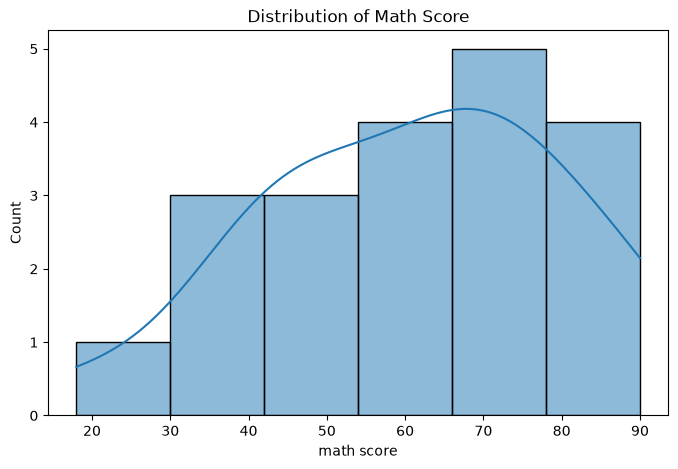

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["math score"], kde=True)
plt.title("Distribution of Math Score")
plt.show()

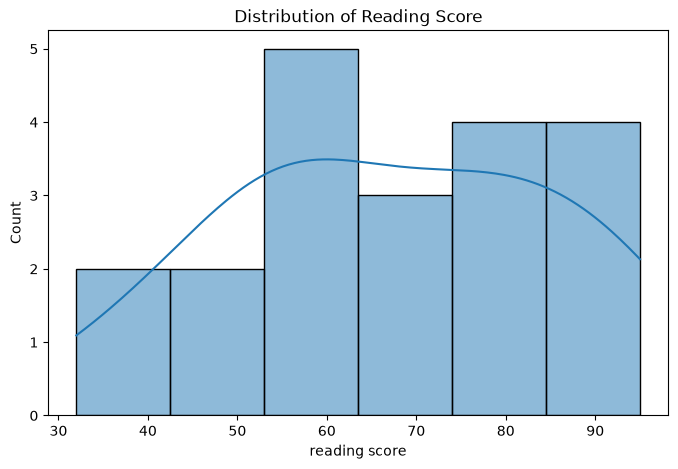

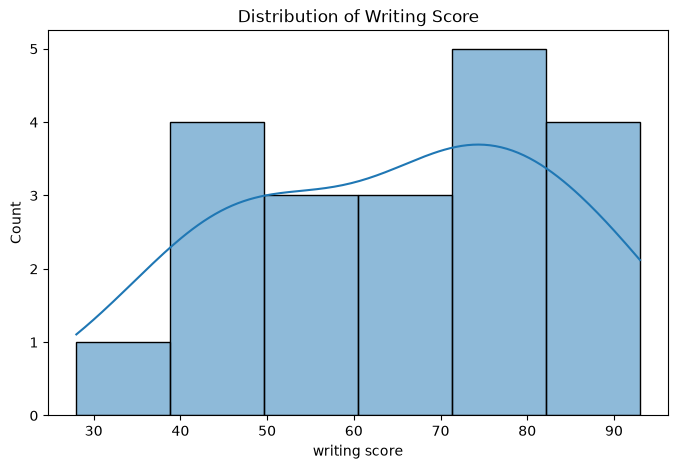

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["reading score"], kde=True)
plt.title("Distribution of Reading Score")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["writing score"], kde=True)
plt.title("Distribution of Writing Score")
plt.show()

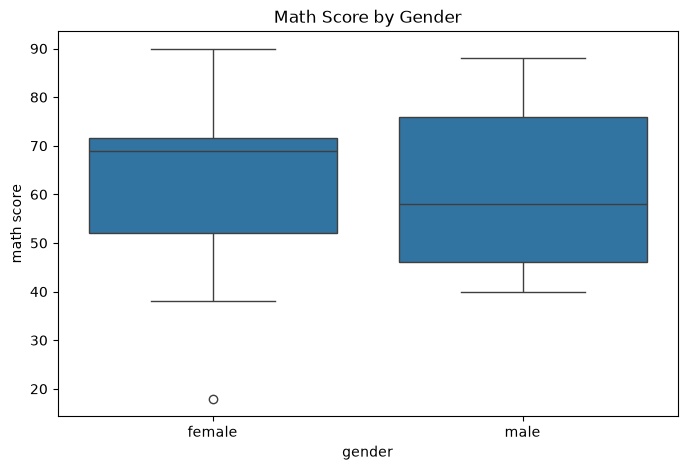

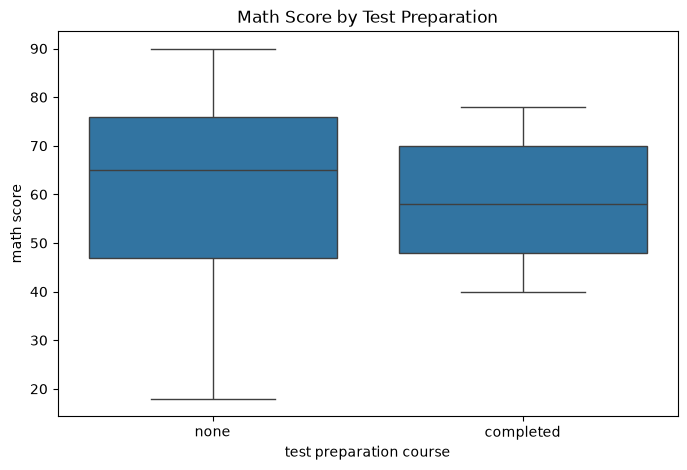

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x="gender", y="math score", data=df)
plt.title("Math Score by Gender")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="test preparation course", y="math score", data=df)
plt.title("Math Score by Test Preparation")
plt.show()

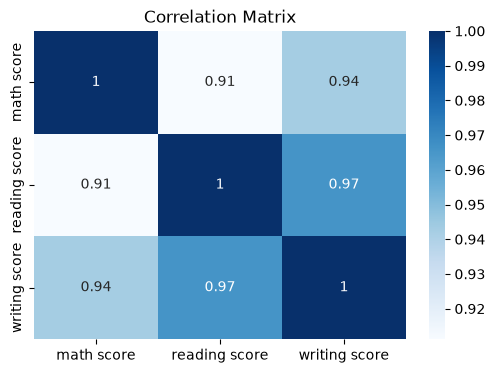

In [9]:
plt.figure(figsize=(6,4))
corr = df[["math score", "reading score", "writing score"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [10]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (16, 7)
Test shape : (4, 7)


In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


C:\Users\USER\AppData\Local\Temp\ipykernel_5388\1263164068.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [14]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [15]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['gender','race/ethnicity','parental level of education',..., 'test preparation course','reading score','writing score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be a

In [16]:
y_pred = model.predict(X_test)
y_pred

array([59.64585039,  8.88086748, 70.08353038, 91.35428017])

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

In [18]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results

,Actual,Predicted
0,72,59.645850
1,18,8.880867
2,69,70.083530
3,69,91.354280


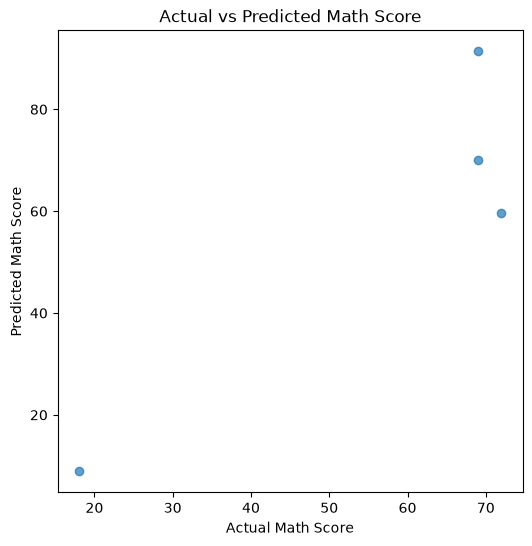

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Score")
plt.show()

## Observations
- Reading score and writing score appear to be strongly related to math score.
- Test preparation course may have an effect on student performance.
- Categorical variables such as parental education and lunch type may also influence the target.
- The baseline linear regression model provides an initial benchmark for future improvement.

## Baseline Model Conclusion

A baseline linear regression model was trained to predict student math scores using demographic and academic features.  
The model achieved an **R² score of 0.638**, which indicates that it can explain around **63.8%** of the variance in math scores on this sample dataset.

Among the available features, **reading score** and **writing score** appear to be the most strongly related to math performance.  
This baseline serves as the first benchmark, and future improvements will include training on a larger real-world dataset and testing stronger models such as Random Forest and XGBoost-style methods.


In [20]:
df_big = pd.read_csv("../data/student_performance_expanded.csv")
df_big.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,associate's degree,free/reduced,none,48,57,44
1,female,group B,some college,standard,none,85,94,97
2,female,group C,high school,standard,none,66,80,68
3,female,group B,high school,free/reduced,none,43,65,54
4,male,group D,some college,standard,completed,75,72,69


In [21]:
print("Expanded dataset shape:", df_big.shape)
print(df_big.isnull().sum())

Expanded dataset shape: (300, 8)
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [22]:
X_big = df_big.drop("math score", axis=1)
y_big = df_big["math score"]

In [23]:
from sklearn.model_selection import train_test_split

X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(
    X_big, y_big, test_size=0.2, random_state=42
)

print("Train shape:", X_train_big.shape)
print("Test shape :", X_test_big.shape)

Train shape: (240, 7)
Test shape : (60, 7)


In [24]:
numeric_features_big = X_big.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_big = X_big.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features_big)
print("Categorical features:", categorical_features_big)

Numeric features: ['reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


C:\Users\USER\AppData\Local\Temp\ipykernel_5388\3920955768.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_big = X_big.select_dtypes(include=["object"]).columns.tolist()


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer_big = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_big = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_big = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_big, numeric_features_big),
        ("cat", categorical_transformer_big, categorical_features_big)
    ]
)

In [26]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor_big),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train_big, y_train_big)
linear_pred = linear_model.predict(X_test_big)

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_big),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=8
    ))
])

rf_model.fit(X_train_big, y_train_big)
rf_pred = rf_model.predict(X_test_big)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 3),
        "MSE": round(mse, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    }

In [29]:
linear_results = evaluate_model(y_test_big, linear_pred, "Linear Regression")
rf_results = evaluate_model(y_test_big, rf_pred, "Random Forest")

results_df = pd.DataFrame([linear_results, rf_results])
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,4.168,25.428,5.043,0.904
1,Random Forest,3.488,20.831,4.564,0.921


In [30]:
results_df.sort_values(by="R2", ascending=False)

,Model,MAE,MSE,RMSE,R2
1,Random Forest,3.488,20.831,4.564,0.921
0,Linear Regression,4.168,25.428,5.043,0.904


In [31]:
rf_compare = pd.DataFrame({
    "Actual": y_test_big.values,
    "Predicted_RF": rf_pred
})

rf_compare.head(15)

,Actual,Predicted_RF
0,81,73.490416
1,53,48.922804
2,52,47.884589
3,73,67.941383
4,41,45.320645
5,60,56.658250
6,87,89.455654
7,87,88.905672
8,91,84.113534
9,71,76.761453


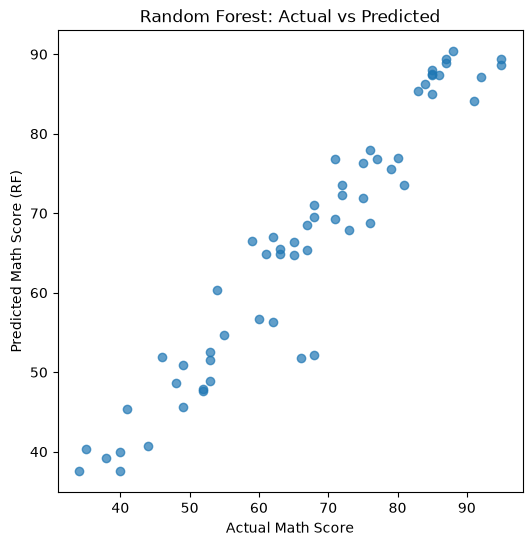

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_big, rf_pred, alpha=0.7)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score (RF)")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [34]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/best_student_score_model.joblib")
print("Model saved successfully!")

Model saved successfully!


## Final Model Comparison Conclusion

Two regression models were trained to predict student math scores:

1. **Linear Regression**
2. **Random Forest Regressor**

The **Random Forest model** achieved the best performance on the expanded dataset, with an **R² score of 0.921**, **RMSE of 4.564**, and **MAE of 3.488**.  
This indicates that the model can explain about **92.1% of the variance** in student math scores and produces relatively low prediction error.

Compared to Linear Regression, Random Forest performed better across all evaluation metrics, making it the preferred model for this project at the current stage.

### Final Selected Model
**Random Forest Regressor**

### Future Improvements
- Use a larger real-world public student performance dataset
- Perform hyperparameter tuning
- Add model explainability / feature importance analysis
- Build a Streamlit web app for interactive score prediction